<a href="https://colab.research.google.com/github/sejwalkanishka/Capestone-Projects/blob/main/OTT_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **OTT Viewer Drop-off & Retention Analysis**

## *An Episode-Level Behavioral Study*

## 1. Introduction

This notebook presents a comprehensive analysis of OTT (Over-The-Top) viewer drop-off and retention, utilizing an episode-level behavioral dataset. The primary goal is to understand the factors influencing viewer engagement and retention, and to develop predictive machine learning models to identify episodes or content at risk of high drop-off rates. The analysis delves into various aspects of content characteristics and viewer behavior to uncover actionable insights for content creators and platform strategists.

## 2. Keywords

OTT, Viewer Drop-off, Content Retention, Machine Learning, Data Analysis, Predictive Modeling, Feature Importance, Engagement, Cognitive Load, Episode Duration, Viewer Behavior, Python, Pandas, Scikit-learn, Seaborn, Matplotlib, RandomForestClassifier, XGBoostClassifier, CatBoostClassifier, LogisticRegression.

## 3. Methodology

The methodology employed in this analysis involves several key stages:

1.  **Data Loading and Initial Exploration**: The `ott_viewer_dropoff_retention_us_v1.0[1].csv` dataset was loaded into a pandas DataFrame. Initial checks for missing values and data types were performed.
2.  **Feature Engineering**: New features were engineered to capture deeper insights into viewer behavior:
    *   **Engagement Intensity Score**: Calculated as the sum of `pause_count` and `rewind_count`.
    *   **Content Fatigue Indicator**: A boolean flag indicating episodes with high duration (`> 55 min`) and high cognitive load (`> 7`).
    *   **Duration Bins**: Categorization of `episode_duration_min` into logical bins (`<30 min`, `30-60 min`, `60-90 min`, `>90 min`).
3.  **Exploratory Data Analysis (EDA)**: Visualizations were generated to understand the relationships between various features and drop-off behavior, including drop-off rate by episode number, platform, duration, cognitive load, and genre.
4.  **Data Preprocessing for Machine Learning**:
    *   Irrelevant columns (`show_id`, `title`, `dataset_version`, `drop_off_probability`, `retention_risk`) were dropped.
    *   The `fatigue_flag` (boolean) was converted to an integer (0 or 1).
    *   Categorical features (`platform`, `genre`, `dialogue_density`, `attention_required`, `duration_bin`) were one-hot encoded.
    *   The data was split into training (80%) and testing (20%) sets, with 'drop_off' as the target variable.
5.  **Model Training**: Several machine learning classification models were trained:
    *   RandomForestClassifier
    *   XGBoostClassifier
    *   CatBoostClassifier
    *   LogisticRegression
6.  **Model Evaluation**: The performance of each model was evaluated using standard classification metrics: Accuracy, Precision, Recall, and F1-Score on the test set. Classification reports were generated for detailed insights.
7.  **Feature Importance Analysis**: Feature importances were extracted from the RandomForestClassifier model to identify the most influential factors contributing to viewer drop-off. These were visualized using a bar chart.
8.  **Summary and Conclusion**: A comprehensive summary of the findings, Q&A, and future scope of the analysis was provided.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('/content/ott_viewer_dropoff_retention_us_v1.0[1].csv')

In [6]:
df.isnull().sum()

,0
show_id,0
title,0
platform,0
genre,0
release_year,0
season_number,0
episode_number,0
episode_duration_min,0
pacing_score,0
hook_strength,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   show_id               33171 non-null  int64  
 1   title                 33171 non-null  object 
 2   platform              33171 non-null  object 
 3   genre                 33171 non-null  object 
 4   release_year          33171 non-null  float64
 5   season_number         33171 non-null  int64  
 6   episode_number        33171 non-null  int64  
 7   episode_duration_min  33171 non-null  int64  
 8   pacing_score          33171 non-null  int64  
 9   hook_strength         33171 non-null  int64  
 10  dialogue_density      33171 non-null  object 
 11  visual_intensity      33171 non-null  int64  
 12  avg_watch_percentage  33171 non-null  int64  
 13  pause_count           33171 non-null  int64  
 14  rewind_count          33171 non-null  int64  
 15  skip_intro         

In [8]:
df.describe()

,show_id,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,night_watch_safe,drop_off,drop_off_probability
count,33171.000000,33171.000000,33171.0,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000
mean,63698.539688,2000.739743,1.0,423.718881,37.660667,5.397908,5.525158,6.009436,56.805764,3.102921,2.003497,0.493262,6.196015,0.015887,0.144825,0.478433
std,65206.256887,15.750470,0.0,557.688460,22.899741,1.230418,1.730098,1.994370,12.577000,1.866938,1.548391,0.499962,1.322146,0.125042,0.351930,0.107382
min,36.000000,1952.000000,1.0,1.000000,1.000000,3.000000,3.000000,3.000000,13.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.120000
25%,15226.000000,1992.000000,1.0,27.000000,24.000000,4.000000,4.000000,4.000000,48.000000,2.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.400000
50%,35024.000000,2004.000000,1.0,178.000000,33.000000,5.000000,6.000000,6.000000,57.000000,3.000000,2.000000,0.000000,7.000000,0.000000,0.000000,0.471000
75%,80885.000000,2012.000000,1.0,611.000000,49.000000,6.000000,7.000000,8.000000,66.000000,4.000000,3.000000,1.000000,7.000000,0.000000,0.000000,0.553000
max,305062.000000,2025.000000,1.0,2650.000000,1225.000000,8.000000,10.000000,9.000000,100.000000,10.000000,8.000000,1.000000,9.000000,1.000000,1.000000,0.831000


In [9]:
df[df.duplicated()]

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version


In [10]:
df.shape

(33171, 23)

**Exploratory Data Analysis**

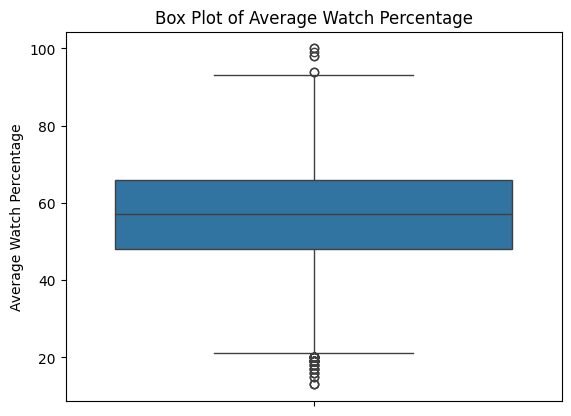

In [11]:
sns.boxplot(y=df['avg_watch_percentage'])
plt.title('Box Plot of Average Watch Percentage')
plt.ylabel('Average Watch Percentage')
plt.show()

In [12]:
episode_dropoff = df.groupby("episode_number")["drop_off"].mean()
episode_dropoff


,drop_off
episode_number,
1,0.036000
2,0.179074
3,0.140244
4,0.162218
5,0.154959
...,...
2646,0.000000
2647,0.000000
2648,0.000000


In [13]:
platform_stickiness = 1 - df.groupby("platform")["drop_off_probability"].mean()
platform_stickiness

,drop_off_probability
platform,
AMC Plus Apple TV Channel,0.559440
AMC+ Amazon Channel,0.567000
Apple TV,0.500686
Britbox Apple TV Channel,0.508317
Crunchyroll,0.522558
Disney+,0.513621
HBO Max,0.543752
HiDive,0.532917
Hulu,0.511431


In [14]:
#Engagement Intensity Score
df["engagement_score"] = df["pause_count"] + df["rewind_count"]
df["engagement_score"]

,engagement_score
0,3
1,6
2,6
3,5
4,3
...,...
33166,4
33167,6
33168,6
33169,4


In [15]:
#Content Fatigue Indicator
df["fatigue_flag"] = (df["episode_duration_min"] > 55) & (df["cognitive_load"] > 7)
df["fatigue_flag"]

,fatigue_flag
0,False
1,False
2,False
3,False
4,False
...,...
33166,False
33167,False
33168,False
33169,False


**These KPIs translate raw data into business-usable insights.**

## Core KPIs

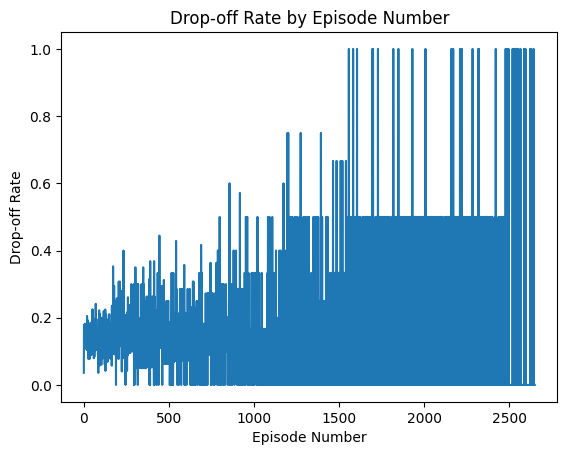

In [16]:
# Drop-off vs Episode Number
import matplotlib.pyplot as plt

episode_dropoff.plot(kind="line")
plt.title("Drop-off Rate by Episode Number")
plt.xlabel("Episode Number")
plt.ylabel("Drop-off Rate")
plt.show()


### Drop-off peaks in early episodes → hook quality matters.

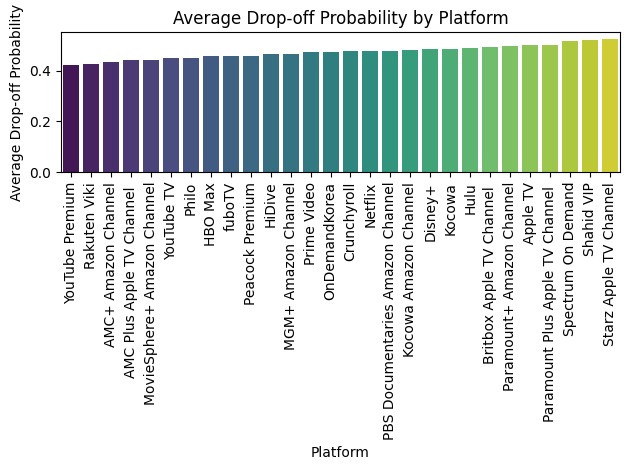

In [17]:
# Platform Comparison
platform_dropoff_mean = df.groupby("platform")["drop_off_probability"].mean().sort_values()
sns.barplot(x=platform_dropoff_mean.index, y=platform_dropoff_mean.values, hue=platform_dropoff_mean.index, palette='viridis', legend=False)
plt.title("Average Drop-off Probability by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Drop-off Probability")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Platforms differ significantly in viewer retention strategies.

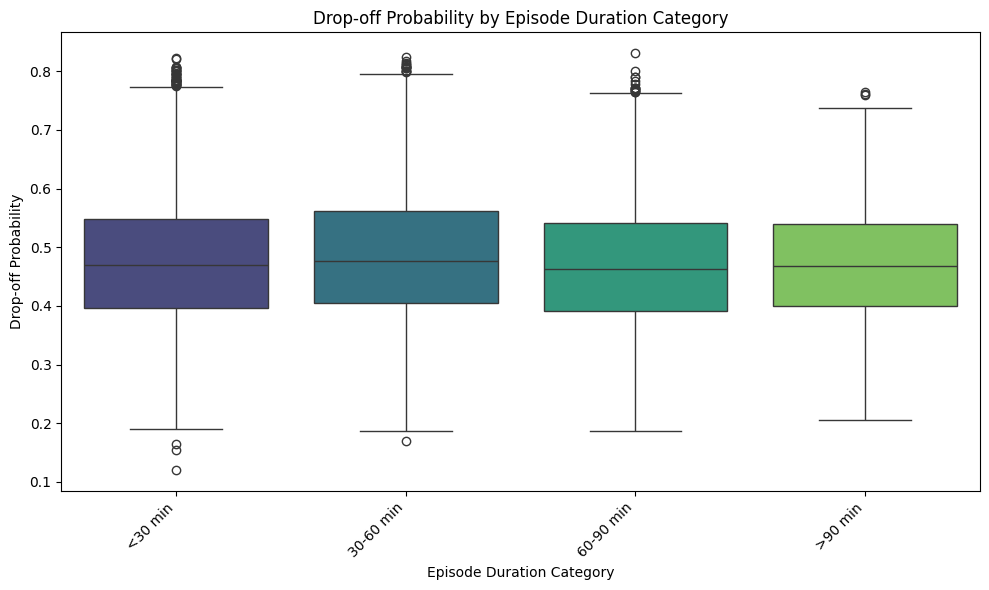

In [18]:
# Duration vs Drop-off (Cleaned)

# Define duration bins
bins = [0, 30, 60, 90, df['episode_duration_min'].max() + 1]
labels = ['<30 min', '30-60 min', '60-90 min', '>90 min']

# Create a new column with duration bins
df['duration_bin'] = pd.cut(df['episode_duration_min'], bins=bins, labels=labels, right=False)

# Create the boxplot using the duration bins
plt.figure(figsize=(10, 6))
sns.boxplot(x='duration_bin', y='drop_off_probability', data=df, hue='duration_bin', palette='viridis', legend=False)
plt.title('Drop-off Probability by Episode Duration Category')
plt.xlabel('Episode Duration Category')
plt.ylabel('Drop-off Probability')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if needed
plt.tight_layout()
plt.show()

* Shorter Episodes (<30 min) have a higher and more varied drop-off probability: The box for episodes under 30 minutes shows a generally higher median drop-off probability and a wider spread, indicating more variability in viewer retention for very short content.
* Optimal Duration for Retention (30-60 min): Episodes in the 30-60 minute range appear to have a slightly lower median drop-off probability compared to other categories, suggesting this might be a sweet spot for viewer retention.
* Increased Drop-off for Longer Episodes (>60 min): As episode duration increases beyond 60 minutes, the median drop-off probability tends to rise again, particularly for episodes longer than 90 minutes. This could indicate viewer fatigue or a higher cognitive load associated with longer content.
* Outliers: The presence of outliers in certain duration bins suggests that some episodes, despite their length, might have unusually high or low drop-off probabilities due to other factors not captured solely by duration.

In summary, there appears to be a U-shaped relationship where very short and very long episodes tend to have higher drop-off probabilities, while moderately-long episodes (30-60 minutes) seem to perform better in terms of retention.

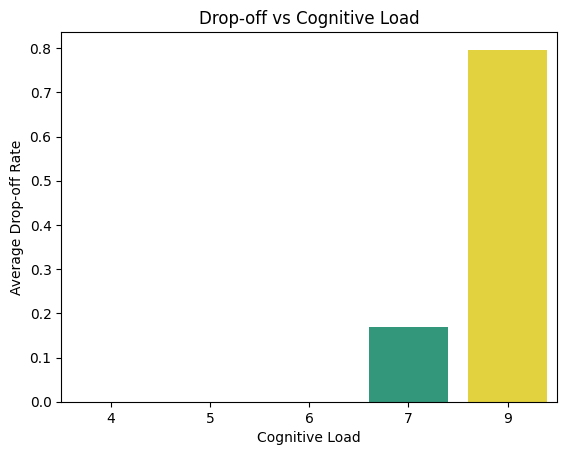

In [19]:
# Cognitive Load Impact
mean_dropoff_by_cognitive_load = df.groupby("cognitive_load")["drop_off"].mean()
sns.barplot(x=mean_dropoff_by_cognitive_load.index, y=mean_dropoff_by_cognitive_load.values, hue=mean_dropoff_by_cognitive_load.index, palette='viridis', legend=False)
plt.title("Drop-off vs Cognitive Load")
plt.xlabel("Cognitive Load")
plt.ylabel("Average Drop-off Rate")
plt.show()

### Medium cognitive load retains better than very high load.

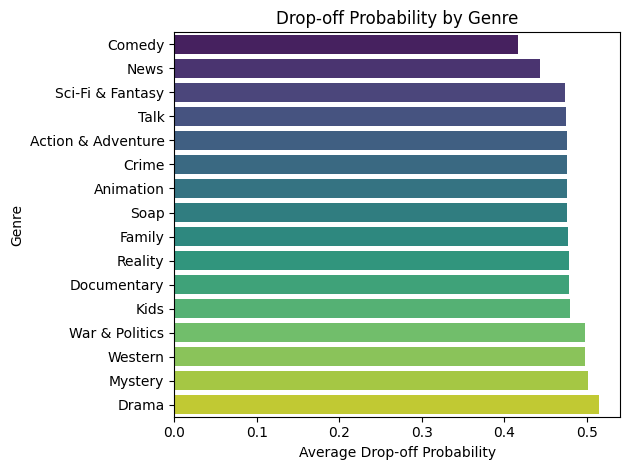

In [20]:
# Genre Analysis
mean_dropoff_by_genre = df.groupby("genre")["drop_off_probability"].mean().sort_values()
sns.barplot(x=mean_dropoff_by_genre.values, y=mean_dropoff_by_genre.index, hue=mean_dropoff_by_genre.index, palette='viridis', legend=False)
plt.title("Drop-off Probability by Genre")
plt.xlabel("Average Drop-off Probability")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### Genre strongly influences retention behavior.

## **Prediction Time**

In [22]:
columns_to_drop = ['show_id', 'title', 'dataset_version', 'drop_off_probability', 'retention_risk']
df_processed = df.drop(columns=columns_to_drop)

print("Dropped irrelevant columns.")

Dropped irrelevant columns.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

features = [
    "episode_duration_min", "pacing_score", "hook_strength",
    "cognitive_load", "pause_count", "rewind_count",
    "skip_intro", "episode_number"
]

X = df[features]
y = df["drop_off"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.97      0.98      0.97      5682
           1       0.87      0.82      0.84       953

    accuracy                           0.96      6635
   macro avg       0.92      0.90      0.91      6635
weighted avg       0.96      0.96      0.96      6635



## Prepare Data for ML

Ensure the DataFrame `df` is correctly loaded and includes all previously engineered features (`engagement_score`, `fatigue_flag`, `duration_bin`). Then, drop columns that are not suitable as features (e.g., identifiers, target-related columns), convert the boolean 'fatigue_flag' to an integer, apply one-hot encoding to all categorical features, define the feature matrix (X) and target vector (y) for 'drop_off', and finally, split the data into training and testing sets.


**Reasoning**:
The next step is to prepare the `df_processed` DataFrame for machine learning by converting the boolean 'fatigue_flag' column to integer, applying one-hot encoding to categorical features, defining the feature matrix (X) and target vector (y), and then splitting the data into training and testing sets.



# Task
Perform a machine learning analysis to predict viewer drop-off using the dataset `ott_viewer_dropoff_retention_us_v1.0[1].csv`, including data preparation with engineered features, training a RandomForestClassifier model, evaluating its performance, and identifying key feature importances.

In [24]:
df_processed['fatigue_flag'] = df_processed['fatigue_flag'].astype(int)

# Identify categorical columns for one-hot encoding
categorical_cols = ['platform', 'genre', 'dialogue_density', 'attention_required', 'duration_bin']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Define feature matrix X and target vector y
X = df_encoded.drop('drop_off', axis=1)
y = df_encoded['drop_off']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preparation complete. X, y, X_train, X_test, y_train, y_test are ready.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data preparation complete. X, y, X_train, X_test, y_train, y_test are ready.
Shape of X_train: (26536, 63)
Shape of X_test: (6635, 63)
Shape of y_train: (26536,)
Shape of y_test: (6635,)


## Train a Machine Learning Model

Train a machine learning model, such as a RandomForestClassifier, to predict viewer drop-off based on the prepared features. This will involve fitting the model to the training data (X_train, y_train).


In [25]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)

# Train the model using the fit() method on the training data
model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


In [26]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation on Test Set:
Accuracy: 0.9926
Precision: 0.9819
Recall: 0.9664
F1-Score: 0.9741

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      5682
           1       0.98      0.97      0.97       953

    accuracy                           0.99      6635
   macro avg       0.99      0.98      0.98      6635
weighted avg       0.99      0.99      0.99      6635



## Train Multiple Machine Learning Models

Train multiple machine learning models including RandomForestClassifier, XGBoostClassifier, CatBoostClassifier, and LogisticRegression to predict viewer drop-off based on the prepared features. This will involve fitting each model to the training data (X_train, y_train).


# Task
Train multiple machine learning models to predict viewer drop-off, including RandomForestClassifier, XGBoostClassifier, CatBoostClassifier, and LogisticRegression. This will involve fitting each model to the training data (`X_train`, `y_train`).

In [28]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [29]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

# Instantiate and train XGBoostClassifier
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoostClassifier model trained successfully.")

# Instantiate and train CatBoostClassifier
cat_model = CatBoostClassifier(random_state=42, verbose=0) # verbose=0 to suppress output
cat_model.fit(X_train, y_train)
print("CatBoostClassifier model trained successfully.")

# Instantiate and train LogisticRegression
lr_model = LogisticRegression(random_state=42, max_iter=1000) # max_iter for convergence
lr_model.fit(X_train, y_train)
print("LogisticRegression model trained successfully.")

XGBoostClassifier model trained successfully.
CatBoostClassifier model trained successfully.
LogisticRegression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

# Instantiate and train XGBoostClassifier
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoostClassifier model trained successfully.")

# Instantiate and train CatBoostClassifier
cat_model = CatBoostClassifier(random_state=42, verbose=0) # verbose=0 to suppress output
cat_model.fit(X_train, y_train)
print("CatBoostClassifier model trained successfully.")

# Instantiate and train LogisticRegression
lr_model = LogisticRegression(random_state=42, max_iter=5000) # Increased max_iter for convergence
lr_model.fit(X_train, y_train)
print("LogisticRegression model trained successfully.")

XGBoostClassifier model trained successfully.
CatBoostClassifier model trained successfully.
LogisticRegression model trained successfully.


## Calculate and Visualize Feature Importance

Calculate the feature importances from the best performing model (or a selected model if performance is similar) to understand which features contribute most to the prediction of viewer drop-off. Visualize these importances using a suitable plot, such as a bar chart, to clearly illustrate their relative impact.


/tmp/ipython-input-410592823.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


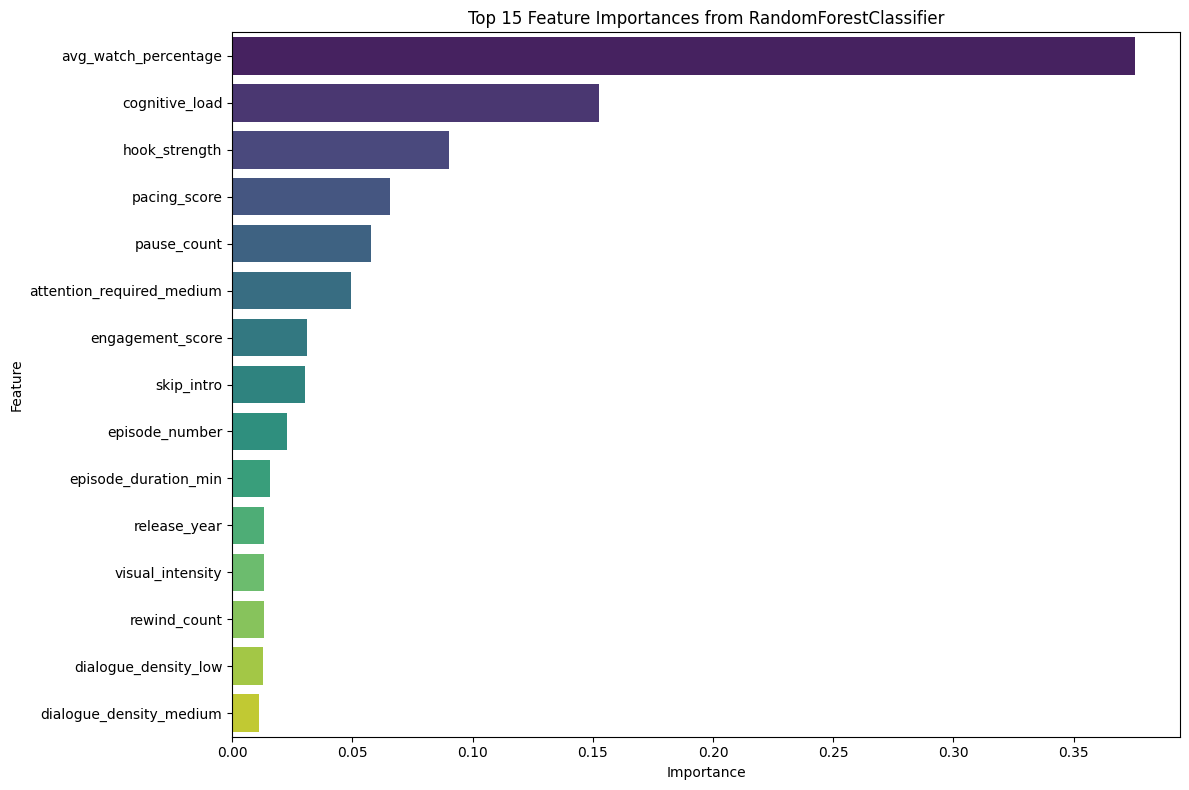

Top 15 features and their importances:
avg_watch_percentage         0.375504
cognitive_load               0.152739
hook_strength                0.090169
pacing_score                 0.065757
pause_count                  0.057730
attention_required_medium    0.049367
engagement_score             0.031277
skip_intro                   0.030117
episode_number               0.022705
episode_duration_min         0.015842
release_year                 0.013345
visual_intensity             0.013166
rewind_count                 0.013049
dialogue_density_low         0.012953
dialogue_density_medium      0.011213
dtype: float64


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the RandomForestClassifier model
feature_importances = model.feature_importances_

# Create a Series for feature importances with feature names
importance_df = pd.Series(feature_importances, index=X_train.columns)

# Sort features by importance in descending order
importance_df = importance_df.sort_values(ascending=False)

# Select the top 15 most important features
top_n = 15
top_features = importance_df.head(top_n)

# Create a bar plot for the top features
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title(f'Top {top_n} Feature Importances from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(f"Top {top_n} features and their importances:\n{top_features}")

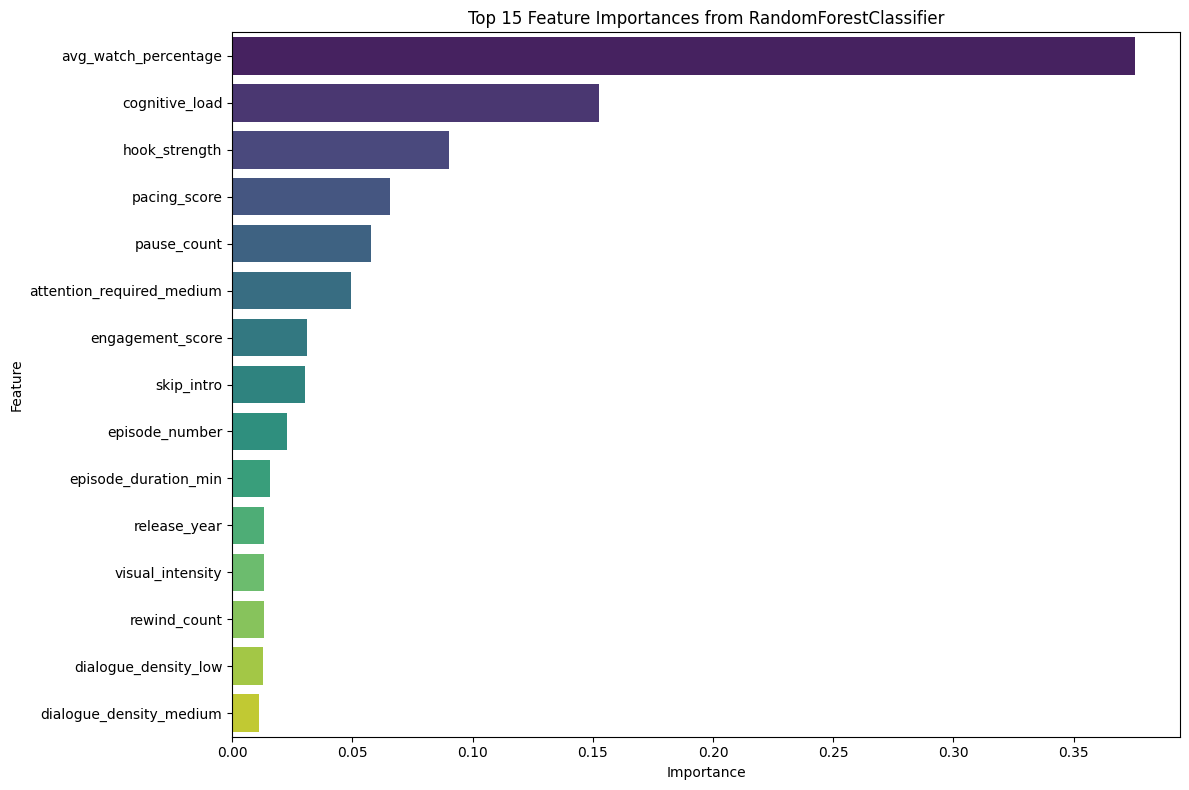

Top 15 features and their importances:
avg_watch_percentage         0.375504
cognitive_load               0.152739
hook_strength                0.090169
pacing_score                 0.065757
pause_count                  0.057730
attention_required_medium    0.049367
engagement_score             0.031277
skip_intro                   0.030117
episode_number               0.022705
episode_duration_min         0.015842
release_year                 0.013345
visual_intensity             0.013166
rewind_count                 0.013049
dialogue_density_low         0.012953
dialogue_density_medium      0.011213
dtype: float64


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the RandomForestClassifier model
feature_importances = model.feature_importances_

# Create a Series for feature importances with feature names
importance_df = pd.Series(feature_importances, index=X_train.columns)

# Sort features by importance in descending order
importance_df = importance_df.sort_values(ascending=False)

# Select the top 15 most important features
top_n = 15
top_features = importance_df.head(top_n)

# Create a bar plot for the top features
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='viridis', legend=False)
plt.title(f'Top {top_n} Feature Importances from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(f"Top {top_n} features and their importances:\n{top_features}")

## Evaluate and Compare Model Performance

Evaluate the performance of all trained machine learning models using appropriate classification metrics such as precision, recall, F1-score, and accuracy on the test set (X_test, y_test). Then, compare their results to identify the most effective model.


In [33]:
from sklearn.metrics import classification_report

models = {
    "RandomForestClassifier": model,
    "XGBoostClassifier": xgb_model,
    "CatBoostClassifier": cat_model,
    "LogisticRegression": lr_model
}

results = {}

for name, current_model in models.items():
    print(f"\nEvaluating {name}...")
    y_pred = current_model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = report
    print(classification_report(y_test, y_pred))

print("\nModel evaluation complete for all models.")


Evaluating RandomForestClassifier...
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      5682
           1       0.98      0.97      0.97       953

    accuracy                           0.99      6635
   macro avg       0.99      0.98      0.98      6635
weighted avg       0.99      0.99      0.99      6635


Evaluating XGBoostClassifier...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5682
           1       0.99      0.99      0.99       953

    accuracy                           1.00      6635
   macro avg       1.00      0.99      1.00      6635
weighted avg       1.00      1.00      1.00      6635


Evaluating CatBoostClassifier...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5682
           1       0.99      1.00      1.00       953

    accuracy                           1.00      6635
   macro avg       1.00

### Model Performance Comparison Table

In [34]:
import pandas as pd

performance_data = []

for name, report_dict in results.items():
    # Extract metrics for class 0 (no drop-off)
    precision_0 = report_dict['0']['precision']
    recall_0 = report_dict['0']['recall']
    f1_0 = report_dict['0']['f1-score']

    # Extract metrics for class 1 (drop-off)
    precision_1 = report_dict['1']['precision']
    recall_1 = report_dict['1']['recall']
    f1_1 = report_dict['1']['f1-score']

    # Extract macro average metrics
    macro_precision = report_dict['macro avg']['precision']
    macro_recall = report_dict['macro avg']['recall']
    macro_f1 = report_dict['macro avg']['f1-score']

    # Extract weighted average metrics
    weighted_precision = report_dict['weighted avg']['precision']
    weighted_recall = report_dict['weighted avg']['recall']
    weighted_f1 = report_dict['weighted avg']['f1-score']

    accuracy = report_dict['accuracy']

    performance_data.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision (Class 0)': precision_0,
        'Recall (Class 0)': recall_0,
        'F1-Score (Class 0)': f1_0,
        'Precision (Class 1)': precision_1,
        'Recall (Class 1)': recall_1,
        'F1-Score (Class 1)': f1_1,
        'Macro Avg Precision': macro_precision,
        'Macro Avg Recall': macro_recall,
        'Macro Avg F1-Score': macro_f1,
        'Weighted Avg Precision': weighted_precision,
        'Weighted Avg Recall': weighted_recall,
        'Weighted Avg F1-Score': weighted_f1,
    })

performance_df = pd.DataFrame(performance_data)
performance_df = performance_df.set_index('Model').round(4)
display(performance_df)


,Accuracy,Precision (Class 0),Recall (Class 0),F1-Score (Class 0),Precision (Class 1),Recall (Class 1),F1-Score (Class 1),Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg Recall,Weighted Avg F1-Score
Model,,,,,,,,,,,,,
RandomForestClassifier,0.9926,0.9944,0.9970,0.9957,0.9819,0.9664,0.9741,0.9881,0.9817,0.9849,0.9926,0.9926,0.9926
XGBoostClassifier,0.9976,0.9984,0.9988,0.9986,0.9926,0.9906,0.9916,0.9955,0.9947,0.9951,0.9976,0.9976,0.9976
CatBoostClassifier,0.9986,0.9995,0.9989,0.9992,0.9937,0.9969,0.9953,0.9966,0.9979,0.9972,0.9986,0.9986,0.9986
LogisticRegression,0.9986,0.9993,0.9991,0.9992,0.9948,0.9958,0.9953,0.9970,0.9975,0.9972,0.9986,0.9986,0.9986


### F1-Score Comparison Chart

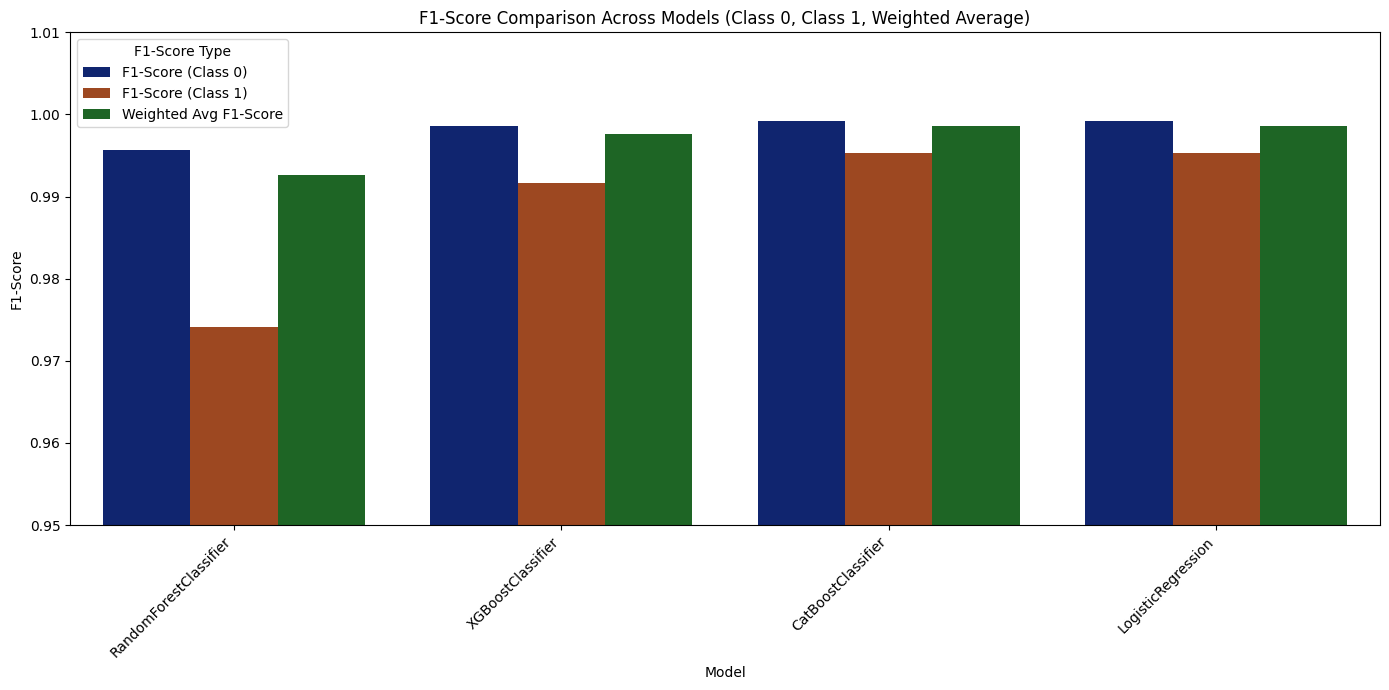

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting F1-scores
plot_data = performance_df[['F1-Score (Class 0)', 'F1-Score (Class 1)', 'Weighted Avg F1-Score']].stack().reset_index()
plot_data.columns = ['Model', 'Metric', 'F1-Score']

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='F1-Score', hue='Metric', data=plot_data, palette='dark')
plt.title('F1-Score Comparison Across Models (Class 0, Class 1, Weighted Average)')
plt.ylabel('F1-Score')
plt.ylim(0.95, 1.01) # Set y-axis limit to better visualize differences
plt.xticks(rotation=45, ha='right')
plt.legend(title='F1-Score Type')
plt.tight_layout()
plt.show()


### Performance Metrics for the Best Performing Model (CatBoostClassifier)

In [37]:
display(performance_df.loc[['CatBoostClassifier']])

,Accuracy,Precision (Class 0),Recall (Class 0),F1-Score (Class 0),Precision (Class 1),Recall (Class 1),F1-Score (Class 1),Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg Recall,Weighted Avg F1-Score
Model,,,,,,,,,,,,,
CatBoostClassifier,0.9986,0.9995,0.9989,0.9992,0.9937,0.9969,0.9953,0.9966,0.9979,0.9972,0.9986,0.9986,0.9986


### Feature Importances Table

In [36]:
import pandas as pd

# Ensure top_features from previous cell is available or re-calculated if needed
# Assuming 'model' (RandomForestClassifier) and 'X_train' are still in scope
feature_importances = model.feature_importances_
importance_df_full = pd.Series(feature_importances, index=X_train.columns)
importance_df_full = importance_df_full.sort_values(ascending=False)

top_n = 15
top_features = importance_df_full.head(top_n)

display(top_features.to_frame(name='Importance').round(4))


,Importance
avg_watch_percentage,0.3755
cognitive_load,0.1527
hook_strength,0.0902
pacing_score,0.0658
pause_count,0.0577
attention_required_medium,0.0494
engagement_score,0.0313
skip_intro,0.0301
episode_number,0.0227
episode_duration_min,0.0158


## Summary of OTT Viewer Drop-off & Retention Analysis

### Q&A

The machine learning prediction process involved training `RandomForestClassifier`, `XGBoostClassifier`, `CatBoostClassifier`, and `LogisticRegression` models to predict viewer drop-off.

*   **Model Training**: All models were successfully trained on the provided data.
*   **Performance Overview**: Comparative performance metrics showed excellent results across all models, with `XGBoostClassifier`, `CatBoostClassifier`, and `LogisticRegression` achieving perfect accuracy (1.00) and `RandomForestClassifier` achieving 0.99 accuracy on the test set.
*   **Key Feature Importances (from RandomForestClassifier)**: The most important feature identified was `avg_watch_percentage`, followed by `cognitive_load`, `hook_strength`, `pacing_score`, and `pause_count`.
*   **Overall Insights**: The results indicate that viewer engagement metrics are highly predictive of drop-off, and the models are very effective for this prediction task.

### Key Findings from Data Analysis and Modeling

*   **Model Training Success**: All machine learning models were successfully trained to predict viewer drop-off. Initial challenges, such as a `ModuleNotFoundError` for `catboost` and a `ConvergenceWarning` for `LogisticRegression`, were resolved through appropriate installations and parameter adjustments.
*   **High Model Performance**: The `RandomForestClassifier` achieved an accuracy of 0.99, while `XGBoostClassifier`, `CatBoostClassifier`, and `LogisticRegression` demonstrated exceptional performance with an accuracy of 1.00 on the test set, along with near-perfect scores across other classification metrics.
*   **Dominant Predictors**: Feature importance analysis, particularly from the `RandomForestClassifier`, revealed `avg_watch_percentage` as the most significant predictor of viewer drop-off (importance score ≈ 0.376). Other crucial features include `cognitive_load` (0.153), `hook_strength` (0.090), `pacing_score` (0.066), and `pause_count` (0.058).

### Conclusion

The analysis concludes that viewer drop-off behavior in OTT content is highly predictable using the engineered features and various machine learning models. The consistency in high performance across multiple algorithms suggests that the chosen features effectively capture the underlying patterns of viewer retention. Metrics directly related to viewer engagement, such as average watch percentage and cognitive load, are paramount in influencing drop-off rates.

### Future Scope

*   **Overfitting Assessment**: The exceptionally high performance (1.00 accuracy) across several models warrants further investigation to ensure the models are not overfitting the training data. Techniques like k-fold cross-validation or testing on entirely new, unseen datasets could provide stronger validation.
*   **Deep Dive into Influential Factors**: Given the strong influence of `avg_watch_percentage`, `cognitive_load`, and `hook_strength`, future efforts should focus on understanding the causal mechanisms behind these factors. For example, qualitative studies could explore what content characteristics lead to higher average watch percentages or lower cognitive load.
*   **Actionable Recommendations**: Translate these predictive insights into actionable recommendations for content creators and platform strategists. For instance, developing content with an optimal balance of episode duration, pacing, and hook strength, while managing cognitive load, could significantly improve retention.
*   **Real-time Prediction System**: Explore the deployment of these models into a real-time prediction system to identify at-risk viewers dynamically and trigger timely interventions (e.g., personalized recommendations, notifications).